In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nx = 41
ny = 41
nt = 120   # time steps
nit = 50   # pressure iterations

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)

rho = 1
nu = 0.1   # viscosity
dt = 0.01

# velocity fields
u = np.zeros((ny, nx))
v = np.zeros((ny, nx))

# pressure field
p = np.zeros((ny, nx))
b = np.zeros((ny, nx))

In [3]:
def build_up_b(b, rho, dt, u, v, dx, dy):
    b[1:-1, 1:-1] = (rho * (1 / dt *
        ((u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
         (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)) -
        ((u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx))**2 -
        2 * ((u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy) *
             (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx)) -
        ((v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy))**2))
    return b

In [4]:
def pressure_poisson(p, dx, dy, b):
    pn = np.empty_like(p)

    for q in range(nit):
        pn = p.copy()

        p[1:-1,1:-1] = (((pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 +
                         (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2) /
                        (2 * (dx**2 + dy**2)) -
                        dx**2 * dy**2 / (2 * (dx**2 + dy**2)) *
                        b[1:-1,1:-1])

        # boundary conditions
        p[:, -1] = p[:, -2]
        p[:, 0] = p[:, 1]
        p[0, :] = p[1, :]
        p[-1, :] = 0

    return p

In [6]:
for n in range(nt):
    un = u.copy()
    vn = v.copy()

    b = build_up_b(b, rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, dx, dy, b)

    u[1:-1,1:-1] = (un[1:-1,1:-1] -
        un[1:-1,1:-1] * dt/dx *
        (un[1:-1,1:-1] - un[1:-1,:-2]) -
        vn[1:-1,1:-1] * dt/dy *
        (un[1:-1,1:-1] - un[:-2,1:-1]) -
        dt/(2*rho*dx) * (p[1:-1,2:] - p[1:-1,:-2]) +
        nu * (dt/dx**2 *
        (un[1:-1,2:] - 2*un[1:-1,1:-1] + un[1:-1,:-2]) +
        dt/dy**2 *
        (un[2:,1:-1] - 2*un[1:-1,1:-1] + un[:-2,1:-1])))

    v[1:-1,1:-1] = (vn[1:-1,1:-1] -
        un[1:-1,1:-1] * dt/dx *
        (vn[1:-1,1:-1] - vn[1:-1,:-2]) -
        vn[1:-1,1:-1] * dt/dy *
        (vn[1:-1,1:-1] - vn[:-2,1:-1]) -
        dt/(2*rho*dy) * (p[2:,1:-1] - p[:-2,1:-1]) +
        nu * (dt/dx**2 *
        (vn[1:-1,2:] - 2*vn[1:-1,1:-1] + vn[1:-1,:-2]) +
        dt/dy**2 *
        (vn[2:,1:-1] - 2*vn[1:-1,1:-1] + vn[:-2,1:-1])))

    # boundary conditions (lid-driven cavity)
    u[0,:] = 0
    u[:,0] = 0
    u[:,-1] = 0
    u[-1,:] = 1   # moving lid

    v[0,:] = 0
    v[-1,:] = 0
    v[:,0] = 0
    v[:,-1] = 0

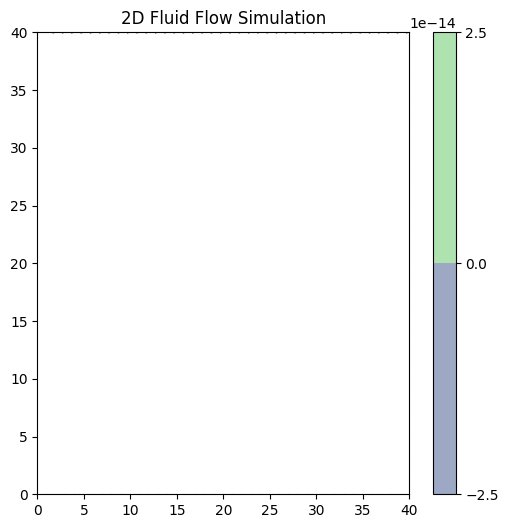

In [7]:
plt.figure(figsize=(6,6))
plt.contourf(p, alpha=0.5)
plt.colorbar()
plt.quiver(u, v)
plt.title("2D Fluid Flow Simulation")
plt.show()